<a href="https://colab.research.google.com/github/NOOBMASTER0016/Sign-language-repo/blob/main/Copy_of_SIGN_LANG_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Plan for Sign Language Detection Model Development

To develop a simple sign language detection model, we will follow these steps:

1.  **Data Loading**: Load the dataset, which typically consists of images or video frames of sign language gestures.
2.  **Data Preprocessing**: Prepare the data for model training. This may include resizing images, normalization, data augmentation, and splitting into training, validation, and test sets.
3.  **Model Building**: Design and implement a simple convolutional neural network (CNN) or a pre-trained model for image classification.
4.  **Model Training**: Train the model using the prepared dataset.
5.  **Model Evaluation**: Assess the model's performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
6.  **Prediction/Inference**: Demonstrate how to use the trained model to make predictions on new data.

### 1. Data Loading

For sign language detection, datasets often consist of images or video frames. We will assume an image-based dataset where images are organized into subfolders representing different sign classes. We'll use `tf.keras.preprocessing.image_dataset_from_directory` to load the data efficiently. You will need to replace `'/path/to/your/dataset'` with the actual path to your sign language image dataset.

Attempting to load image from: /content/sample_data/WhatsApp Image 2026-07-06 at 12.30.00 AM.jpeg
Successfully loaded and preprocessed image. Shape: (1, 128, 128, 3)


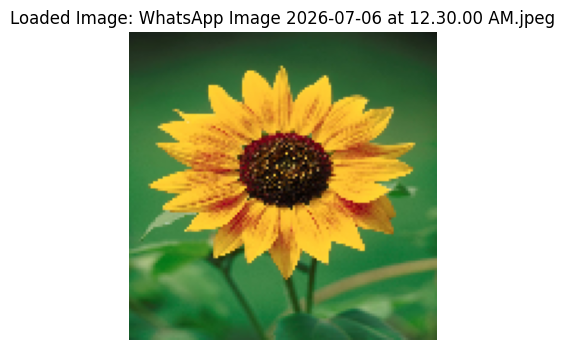

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os # Re-import os for os.path.basename

# Install imageio and imageio-ffmpeg for AVIF support
try:
    import imageio.v3 as iio
except ImportError:
    print("imageio not found. Installing...")
    !pip install imageio imageio-ffmpeg
    import imageio.v3 as iio

# Define parameters for image processing
IMG_HEIGHT = 128
IMG_WIDTH = 128

# The path to the specific image file. Using an existing JPEG from sample_data.
IMAGE_FILE_PATH = '/content/sample_data/WhatsApp Image 2026-07-06 at 12.30.00 AM.jpeg'

print(f"Attempting to load image from: {IMAGE_FILE_PATH}")

try:
    # Read the image using imageio
    img_np = iio.imread(IMAGE_FILE_PATH)
    # Convert NumPy array to TensorFlow tensor
    img = tf.convert_to_tensor(img_np, dtype=tf.float32)

    # Ensure 3 channels for RGB, if necessary (e.g., if image was grayscale)
    if img.shape[-1] == 4: # If RGBA, convert to RGB
        img = img[..., :3]
    elif img.shape[-1] == 1: # If grayscale, convert to RGB
        img = tf.image.grayscale_to_rgb(tf.expand_dims(img, axis=-1))

    # Resize the image
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    # Normalize the image to [0, 1] range
    img = img / 255.0

    # Expand dimensions to create a batch of 1 image (required for model prediction later)
    img_batch = tf.expand_dims(img, axis=0)

    print(f"Successfully loaded and preprocessed image. Shape: {img_batch.shape}")

    # Display the preprocessed image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Loaded Image: {os.path.basename(IMAGE_FILE_PATH)}")
    plt.axis('off')
    plt.show()

except tf.errors.NotFoundError:
    print(f"Error: Image file not found at {IMAGE_FILE_PATH}. Please ensure the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    print("Please check if the file is a valid image and if imageio was installed correctly.")

# These variables are no longer directly relevant for single image loading
train_ds = None
val_ds = None
class_names = None
num_classes = None
AUTOTUNE = None

### 2. Data Preprocessing: Loading a Sign Language Image Dataset

Now, let's load a full dataset for training and validation. This assumes your dataset is organized in a standard directory structure where subfolders represent different classes (e.g., `dataset/class_a/img1.jpg`, `dataset/class_b/img2.jpg`).

**Important:** You need to replace `DATASET_PATH` with the actual path to your sign language image dataset on Google Drive or in your Colab environment.

In [ ]:
import tensorflow as tf

# Define the path to your sign language dataset
# IMPORTANT: Replace this with the actual path to your dataset!
# Example: DATASET_PATH = '/content/gdrive/MyDrive/sign_language_data'
DATASET_PATH = '/path/to/your/sign_language_dataset' # <-- **UPDATE THIS PATH**

# Define image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32 # Standard batch size for training

# Create training and validation datasets
try:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)

    print(f"Found {num_classes} classes: {class_names}")
    print(f"Number of training batches: {len(train_ds)}")
    print(f"Number of validation batches: {len(val_ds)}")

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure your DATASET_PATH is correct and contains subdirectories for classes.")
    print("Example structure: `dataset_root/class_a/img1.jpg`, `dataset_root/class_b/img2.jpg`")


# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

if 'train_ds' in locals() and train_ds is not None and 'val_ds' in locals() and val_ds is not None:
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
    print("Datasets configured for performance (caching, shuffling, prefetching).")
else:
    print("Datasets could not be configured for performance as they were not loaded successfully.")

Error loading dataset: [Errno 2] No such file or directory: '/path/to/your/sign_language_dataset'
Please ensure your DATASET_PATH is correct and contains subdirectories for classes.
Example structure: `dataset_root/class_a/img1.jpg`, `dataset_root/class_b/img2.jpg`
Datasets could not be configured for performance as they were not loaded successfully.


Let's visualize a few images from the training dataset to ensure everything loaded correctly.

In [ ]:
import matplotlib.pyplot as plt

if train_ds:
    plt.figure(figsize=(10, 10))
    for images, labels in train_ds.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.show()
else:
    print("Cannot display images, training dataset not loaded.")

Cannot display images, training dataset not loaded.


### Loading Sign Language Data from CSV Files

It appears the sign language data is provided in CSV files (`sign_mnist_train.csv` and `sign_mnist_test.csv`). I will load these into pandas DataFrames and inspect their structure to understand how to process them into images and labels.

In [ ]:
import pandas as pd

# Define paths to the CSV files
TRAIN_CSV_PATH = '/content/sample_data/sign_mnist_train.csv'
TEST_CSV_PATH = '/content/sample_data/sign_mnist_test.csv'

# Load the training and testing datasets
try:
    train_df = pd.read_csv(TRAIN_CSV_PATH)
    test_df = pd.read_csv(TEST_CSV_PATH)

    print("Training data loaded successfully. Shape:", train_df.shape)
    print("Test data loaded successfully. Shape:", test_df.shape)

except FileNotFoundError:
    print(f"Error: CSV file not found. Please ensure {TRAIN_CSV_PATH} and {TEST_CSV_PATH} exist.")
except Exception as e:
    print(f"An error occurred while loading CSV files: {e}")

Training data loaded successfully. Shape: (27455, 785)
Test data loaded successfully. Shape: (7172, 785)


Let's examine the first few rows of the training DataFrame and its information to understand its columns and data types.

In [ ]:
print("\nTraining DataFrame Head:")
display(train_df.head())

print("\nTraining DataFrame Info:")
train_df.info()


Training DataFrame Head:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179



Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB


And the first few rows of the test DataFrame and its information.

In [ ]:
print("\nTest DataFrame Head:")
display(test_df.head())

print("\nTest DataFrame Info:")
test_df.info()


Test DataFrame Head:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53



Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7172 entries, 0 to 7171
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 43.0 MB


### 2.1. Processing CSV Data into TensorFlow Datasets

Based on the CSV structure, we'll extract pixel data and labels, reshape the pixels into 28x28 images, and normalize them. Then, we'll convert these into TensorFlow datasets for efficient training.

In [ ]:
import numpy as np
import tensorflow as tf

# Adjust image dimensions based on the CSV data (784 pixels = 28x28)
IMG_HEIGHT = 28
IMG_WIDTH = 28

# Extract labels and pixel data
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Reshape pixel data to image format (height, width, channels) and normalize
# Assuming grayscale images, so channels=1
X_train = X_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1).astype('float32') / 255.0

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Determine the number of classes and class names from the training labels
original_class_labels = sorted(np.unique(y_train))
num_classes = len(original_class_labels)

# Create a mapping from original labels to a contiguous range [0, num_classes - 1]
label_mapping = {original_label: new_label for new_label, original_label in enumerate(original_class_labels)}

# Apply the mapping to y_train and y_test
y_train_mapped = np.array([label_mapping[label] for label in y_train])
y_test_mapped = np.array([label_mapping[label] for label in y_test])

# Update class_names to be based on the mapped labels for visualization and interpretation
class_names = [str(label) for label in original_class_labels] # Keep original names, but access with mapped index

print(f"Detected {num_classes} classes. Original labels: {original_class_labels}")
print(f"Labels mapped to range [0, {num_classes - 1}].")

# Create TensorFlow datasets using mapped labels
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_mapped))
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_mapped))

# Configure datasets for performance
train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

print("TensorFlow datasets created and configured for performance.")

X_train shape: (27455, 28, 28, 1), y_train shape: (27455,)
X_test shape: (7172, 28, 28, 1), y_test shape: (7172,)
Detected 24 classes. Original labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Labels mapped to range [0, 23].
TensorFlow datasets created and configured for performance.


Let's visualize a few images from the newly created training dataset to confirm the data processing was correct.

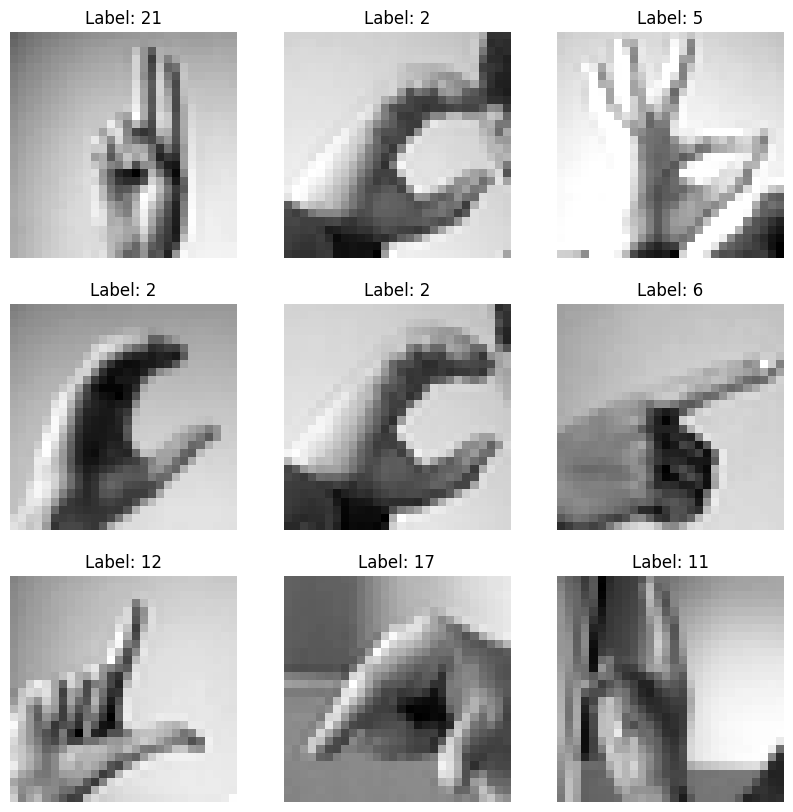

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
i = 0
for images, labels in train_ds.take(1):
    for j in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[j].numpy().squeeze(), cmap='gray') # squeeze() removes channel dim for grayscale
        plt.title(f"Label: {class_names[labels[j].numpy()]}")
        plt.axis("off")
        i += 1
plt.show()